In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

qb_stats = pd.read_csv("data/qb_stats.csv")
cap = pd.read_csv("data/cap_tables.csv")

In [2]:
cap_qb = cap[cap['pos'] == 'QB']

In [3]:
qb_stats = qb_stats.rename(columns={"Player": "name", "Year": "year"})
cap_qb = cap_qb.rename(columns={"name": "name", "season": "year"})


In [4]:
combined = qb_stats.merge(
    cap_qb[['name', 'year', 'cap_hit', 'team']],
    on=['name', 'year'],
    how='inner'   # keeps only matching years
)


In [5]:
X = combined.iloc[:,2:17]
y = combined["cap_hit"]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
draft = pd.read_csv("data/qb_index_no_tier.csv")

In [8]:
draft = draft.rename(columns={
    "year-drafted": "draft_year",
    "rd-picked": "draft_round"
})


In [9]:
combined2 = combined.merge(
    draft[['name', 'draft_year', 'draft_round']],
    on='name',
    how='left'
)

In [10]:
combined2["team_short"] = combined2["team"].str.split("-").str[-1].str.title()
# Years since the QB was drafted
combined2['years_since_draft'] = combined2['year'] - combined2['draft_year']

# Best-realism rookie contract flag
combined2['rookie_contract'] = (
    # 1st-round picks: rookie deal for first 5 years
    ((combined2['draft_round'] == 1) & (combined2['years_since_draft'] < 5))
    |
    # 2nd+ round picks: rookie deal for first 4 years
    ((combined2['draft_round'] > 1) & (combined2['years_since_draft'] < 4))
    |
    # Undrafted players (no draft_round): treat as on rookie-type deals early on
    (combined2['draft_round'].isna())
)
veteran_df = combined2[combined2["rookie_contract"] == False].copy()


In [11]:
veteran_df['td_rate'] = veteran_df['TD'] / veteran_df['Att']
veteran_df['int_rate'] = veteran_df['INT'] / veteran_df['Att']
veteran_df['sack_rate'] = veteran_df['Sck'] / veteran_df['Att']

combined2.loc[:, 'td_rate'] = combined2['TD'] / combined2['Att']
combined2.loc[:, 'int_rate'] = combined2['INT'] / combined2['Att']
combined2.loc[:, 'sack_rate'] = combined2['Sck'] / combined2['Att']



In [12]:
features = [
    "Att",
    "Yds/Att",
    "Cmp %",
    "TD",
    "INT",
    "20+",
    "Sck"
]



In [13]:
veteran_df = combined2[
    (combined2['rookie_contract'] == False) &
    (combined2['cap_hit'].notna()) &
    (combined2['Att'].notna())
].copy()
veteran_df = veteran_df[veteran_df['Att'] >= 225]


In [14]:
X = veteran_df[features]
y = veteran_df['cap_hit']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [16]:
from sklearn.linear_model import LinearRegression

veteran_model = LinearRegression()
veteran_model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = veteran_model.predict(X_test)

print("R² score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": veteran_model.coef_
})

print(coef_df)
print("Intercept:", veteran_model.intercept_)

R² score: 0.20224739588175888
MAE: 4280773.0551665
   feature   coefficient
0      Att  3.046153e+04
1  Yds/Att -1.481731e+06
2    Cmp %  5.408234e+05
3       TD  2.690245e+04
4      INT -9.246170e+04
5      20+  7.616906e+04
6      Sck -8.432453e+03
Intercept: -26118467.453269947


In [18]:
# === GROUPED FEATURE SETS ===

feature_groups = {
    "volume": ["Att", "Cmp", "Pass Yds"],
    "efficiency": ["Yds/Att", "Rate"],
    "accuracy": ["Cmp %"],
    "touchdowns": ["TD", "td_rate"],
    "turnovers": ["INT", "int_rate"],
    "explosive": ["20+", "40+", "Lng", "1st", "1st%"],
    "sacks": ["Sck", "SckY", "sack_rate"],
}


target = "cap_hit"   # or predicted_veteran_salary if you switched earlier

representatives = {}

for group_name, cols in feature_groups.items():
    existing = [c for c in cols if c in veteran_df.columns]
    if len(existing) == 0:
        continue

    corrs = (
        veteran_df[existing + [target]]
        .corr()[target]
        .drop(labels=[target])          # <- remove cap_hit itself
        .abs()
        .sort_values(ascending=False)
    )
    best = corrs.index[0]
    representatives[group_name] = best

print(representatives)



{'volume': 'Cmp', 'efficiency': 'Rate', 'accuracy': 'Cmp %', 'touchdowns': 'TD', 'turnovers': 'int_rate', 'explosive': '1st', 'sacks': 'SckY'}


In [19]:
group_features = list(representatives.values())
group_features

import statsmodels.api as sm

def forward_selection(df, candidate_groups, target):
    selected = []
    remaining = candidate_groups.copy()

    while remaining:
        best_feature = None
        best_adj_r2 = -np.inf

        for feat in remaining:
            trial = selected + [feat]
            X = sm.add_constant(df[trial])
            y = df[target]

            model = sm.OLS(y, X).fit()
            if model.rsquared_adj > best_adj_r2:
                best_adj_r2 = model.rsquared_adj
                best_feature = feat

        # stop if adding doesn’t improve
        if len(selected) > 0:
            full = sm.OLS(df[target], sm.add_constant(df[selected])).fit()
            if best_adj_r2 <= full.rsquared_adj:
                break

        selected.append(best_feature)
        remaining.remove(best_feature)

    return selected

forward_selected = forward_selection(veteran_df, group_features, target)
print("Forward selection chose:", forward_selected)


Forward selection chose: ['Cmp', 'Rate', '1st', 'TD']


In [20]:
def backward_selection(df, features, target):
    selected = features.copy()

    improved = True
    while improved and len(selected) > 1:
        improved = False
        best_adj_r2 = sm.OLS(df[target], sm.add_constant(df[selected])).fit().rsquared_adj
        worst_feature = None

        for feat in selected:
            trial = [f for f in selected if f != feat]
            model = sm.OLS(df[target], sm.add_constant(df[trial])).fit()

            if model.rsquared_adj > best_adj_r2:
                best_adj_r2 = model.rsquared_adj
                worst_feature = feat
                improved = True

        if improved:
            selected.remove(worst_feature)

    return selected

backward_selected = backward_selection(veteran_df, group_features, target)
print("Backward selection chose:", backward_selected)



Backward selection chose: ['Cmp', 'Cmp %', 'TD', '1st', 'SckY']


In [21]:
print("\n=== FORWARD MODEL ===")
Xf = sm.add_constant(veteran_df[forward_selected])
yf = veteran_df[target]
forward_model = sm.OLS(yf, Xf).fit()
print(forward_model.summary())

print("\n=== BACKWARD MODEL ===")
Xb = sm.add_constant(veteran_df[backward_selected])
yb = veteran_df[target]
backward_model = sm.OLS(yb, Xb).fit()
print(backward_model.summary())



=== FORWARD MODEL ===
                            OLS Regression Results                            
Dep. Variable:                cap_hit   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     18.66
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           1.16e-11
Time:                        14:52:56   Log-Likelihood:                -1897.4
No. Observations:                 112   AIC:                             3805.
Df Residuals:                     107   BIC:                             3818.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.007e+07   6.56e

In [22]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Choose one set of features
forward_features = ["Cmp", "Rate", "1st", "TD"]
backward_features = ["Cmp", "Cmp %", "TD", "1st", "SckY"]

# Pick one to run Ridge on
features = forward_features  # or backward_features

X = veteran_df[features].copy()
y = veteran_df["cap_hit"]

# RidgeCV with many plausible alpha values
ridge = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", RidgeCV(alphas=[0.1, 1, 10, 100, 300, 1000, 3000, 10000], cv=5))
])

ridge.fit(X, y)

alpha = ridge.named_steps["ridge"].alpha_
coeffs = ridge.named_steps["ridge"].coef_
r2 = ridge.score(X, y)

print("Best alpha:", alpha)
print("R²:", r2)
print("\nCoefficients:")
for f, c in zip(features, coeffs):
    print(f"{f:>8}: {c:,.2f}")


Best alpha: 1.0
R²: 0.4091992104474589

Coefficients:
     Cmp: 6,418,892.13
    Rate: 953,653.23
     1st: -3,382,643.32
      TD: 1,091,407.96


In [23]:
selected_features = list(representatives.values())

X = veteran_df[selected_features]
y = veteran_df["cap_hit"]

ridge = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", RidgeCV(alphas=[0.1,1,10,100,300,1000,3000,10000], cv=5))
])

ridge.fit(X, y)

alpha = ridge.named_steps["ridge"].alpha_
coeffs = ridge.named_steps["ridge"].coef_
r2 = ridge.score(X, y)

print("Selected features:", selected_features)
print("Best alpha:", alpha)
print("R²:", r2)

for f, c in zip(selected_features, coeffs):
    print(f"{f:>8}: {c:,.2f}")


Selected features: ['Cmp', 'Rate', 'Cmp %', 'TD', 'int_rate', '1st', 'SckY']
Best alpha: 10.0
R²: 0.40483919723550066
     Cmp: 2,504,592.41
    Rate: -749,857.44
   Cmp %: 1,259,630.47
      TD: 1,497,041.08
int_rate: -715,188.04
     1st: -160,283.23
    SckY: 682,382.30


In [24]:
import itertools
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline

best_r2 = -1
best_combo = None
best_model = None

reps = ['Cmp', 'Rate', 'Cmp %', 'TD', 'int_rate', '1st', 'SckY']
alphas = [0.1, 1, 10, 100, 300, 1000, 3000, 10000]

for k in range(3, len(reps)+1):
    for combo in itertools.combinations(reps, k):
        X = veteran_df[list(combo)]
        y = veteran_df["cap_hit"]

        ridge = Pipeline([
            ("scale", StandardScaler()),
            ("ridge", RidgeCV(alphas=alphas, cv=5))
        ])

        ridge.fit(X, y)
        r2 = ridge.score(X, y)

        if r2 > best_r2:
            best_r2 = r2
            best_combo = combo
            best_model = ridge

print("Best Group Combo:", best_combo)
print("Best R²:", best_r2)
print("Best Alpha:", best_model.named_steps["ridge"].alpha_)


Best Group Combo: ('Cmp', 'Cmp %', 'TD', 'int_rate', '1st', 'SckY')
Best R²: 0.41709541358581004
Best Alpha: 1.0


In [25]:
# Step 1: Must be drafted & within first 4 NFL seasons
rookie_df = combined2[
    (combined2['draft_year'].notna()) &
    (combined2['years_since_draft'] < 4)
].copy()

# Step 2: Remove any possible 5th-year option cases
rookie_df = rookie_df[~(
    (rookie_df['draft_round'] == 1) &
    (rookie_df['years_since_draft'] == 4)
)]

# Step 3: Remove extensions or renegotiations
MAX_ROOKIE_CAP_HIT = 8_000_000
rookie_df = rookie_df[rookie_df['cap_hit'] <= MAX_ROOKIE_CAP_HIT]

# Step 4: Keep only majority starters (>=230 attempts)
MIN_ATTEMPTS = 230
rookie_df = rookie_df[rookie_df['Att'] >= MIN_ATTEMPTS]

rookie_df = rookie_df.copy()


In [26]:
rookie_df["team_short"] = rookie_df["team"].str.split("-").str[-1].str.title()


In [27]:
final_features = ['Cmp', 'Cmp %', 'TD', 'int_rate', '1st', 'SckY']

# Build X for veterans (for refitting, just to be safe)
X_vet = veteran_df[final_features].copy()
y_vet = veteran_df["cap_hit"]

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

best_model = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

best_model.fit(X_vet, y_vet)
print("Veteran R²:", best_model.score(X_vet, y_vet))



Veteran R²: 0.41709541358581004


In [28]:
# 1. Build rookie feature matrix with the SAME columns
X_rookies = rookie_df[final_features].copy()

# 2. Drop rows with missing data in any of these features
valid_mask = X_rookies.notna().all(axis=1)

rookie_df_clean = rookie_df[valid_mask].copy()
X_rookies_clean = X_rookies[valid_mask]

# 3. Predict and compute surplus value
rookie_df_clean["predicted_veteran_salary"] = best_model.predict(X_rookies_clean)

rookie_df_clean["surplus_value"] = (
    rookie_df_clean["predicted_veteran_salary"] - rookie_df_clean["cap_hit"]
)

# If you also have salary_cap in this df and want a % version:
# rookie_df_clean["surplus_pct"] = rookie_df_clean["surplus_value"] / rookie_df_clean["salary_cap"]

# 4. If you want to overwrite rookie_df with the enriched, NaN-free version:
rookie_df = rookie_df_clean

# 5. Quick check of top surplus seasons
rookie_df.sort_values("surplus_value", ascending=False)[
    ["year", "name", "team_short", "cap_hit", "predicted_veteran_salary", "surplus_value"]
].head(10)


,year,name,team_short,cap_hit,predicted_veteran_salary,surplus_value
269,2015,Kirk Cousins,Redskins,778172,2.057017e+07,1.979200e+07
121,2018,Dak Prescott,Cowboys,725848,2.013528e+07,1.940943e+07
108,2018,Patrick Mahomes,Chiefs,3733141,2.173555e+07,1.800241e+07
272,2015,Derek Carr,Raiders,1220864,1.891800e+07,1.769713e+07
321,2014,Ryan Tannehill,Dolphins,3455046,2.036166e+07,1.690662e+07
219,2016,Derek Carr,Raiders,1465037,1.816921e+07,1.670417e+07
59,2019,Dak Prescott,Cowboys,2120849,1.857295e+07,1.645211e+07
5,2020,Justin Herbert,Chargers,4832501,2.114565e+07,1.631315e+07
117,2018,Deshaun Watson,Texans,3148700,1.924247e+07,1.609377e+07
329,2014,Derek Carr,Raiders,976691,1.682897e+07,1.585228e+07


In [29]:
rookie_value_table = rookie_df[[
    'name', 'year', 'cap_hit',
    'predicted_veteran_salary', 'surplus_value'
]].sort_values(by='surplus_value', ascending=False)

rookie_value_table.tail()


,name,year,cap_hit,predicted_veteran_salary,surplus_value
286,Nick Foles,2015,4042000,7.092886e+06,3.050886e+06
180,Mitchell Trubisky,2017,5278622,8.237059e+06,2.958437e+06
128,Jameis Winston,2018,7941903,1.038734e+07,2.445433e+06
136,Josh Allen,2018,3851461,5.542629e+06,1.691168e+06
289,Andrew Luck,2015,7034363,5.210928e+06,-1.823435e+06


In [30]:
# Take top 20 rookie seasons by surplus value
top20 = rookie_df.sort_values(by='surplus_value', ascending=False).head(20)
top20['label'] = top20['name'] + " (" + top20['year'].astype(str) + ")"

C:\Users\lpmbe\AppData\Local\Temp\ipykernel_25704\2114585881.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
C:\Users\lpmbe\AppData\Local\Temp\ipykernel_25704\2114585881.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


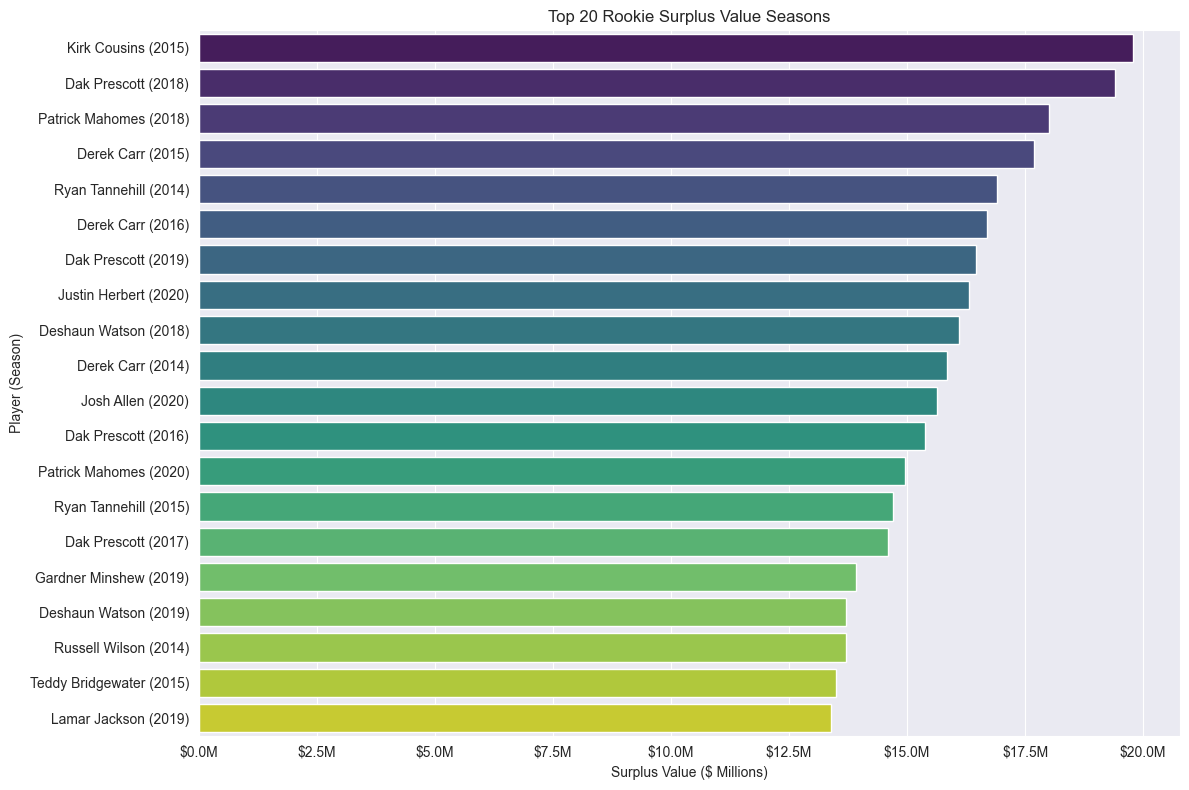

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=top20,
    x='surplus_value',
    y='label',          # the combined name + year column
    palette='viridis',
    ci=None,
    order=top20['label']
)

# Format x-axis as $XM
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M'))

plt.title("Top 20 Rookie Surplus Value Seasons")
plt.xlabel("Surplus Value ($ Millions)")
plt.ylabel("Player (Season)")
plt.tight_layout()
plt.show()


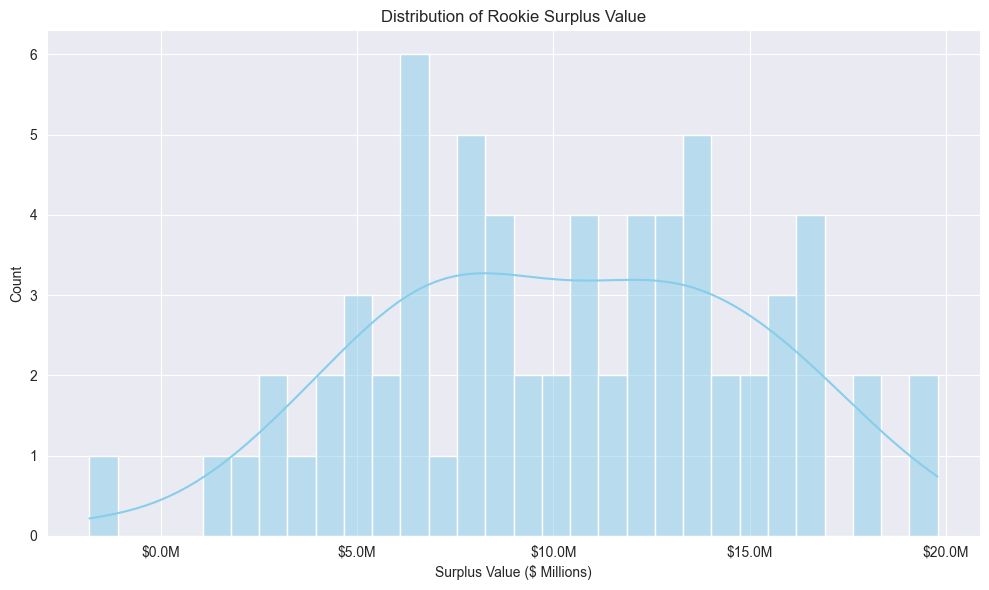

In [32]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(rookie_df['surplus_value'], bins=30, kde=True, color='skyblue')

# Format x-axis
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M'))

plt.title("Distribution of Rookie Surplus Value")
plt.xlabel("Surplus Value ($ Millions)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [33]:
# Bottom 10 seasons by surplus value (most negative)
bottom10 = rookie_df.sort_values(by='surplus_value', ascending=True).head(10)

bottom10[['name', 'year', 'team_short', 'cap_hit', 'predicted_veteran_salary', 'surplus_value', 'Att', 'Rate', 'years_since_draft', 'draft_round']]


,name,year,team_short,cap_hit,predicted_veteran_salary,surplus_value,Att,Rate,years_since_draft,draft_round
289,Andrew Luck,2015,Colts,7034363,5.210928e+06,-1.823435e+06,293,74.9,3.0,1.0
136,Josh Allen,2018,Bills,3851461,5.542629e+06,1.691168e+06,320,67.9,0.0,1.0
128,Jameis Winston,2018,Buccaneers,7941903,1.038734e+07,2.445433e+06,378,90.2,3.0,1.0
180,Mitchell Trubisky,2017,Bears,5278622,8.237059e+06,2.958437e+06,330,77.5,0.0,1.0
286,Nick Foles,2015,Rams,4042000,7.092886e+06,3.050886e+06,337,69.0,3.0,3.0
30,Tua Tagovailoa,2020,Dolphins,5504625,8.972890e+06,3.468265e+06,290,87.0,0.0,1.0
131,Marcus Mariota,2018,Titans,7704446,1.208350e+07,4.379056e+06,331,92.3,3.0,1.0
129,Sam Darnold,2018,Jets,5499584,1.010691e+07,4.607321e+06,414,77.6,0.0,1.0
331,Cam Newton,2014,Panthers,7008113,1.175321e+07,4.745099e+06,448,82.1,3.0,1.0
168,Jameis Winston,2017,Buccaneers,6913985,1.212001e+07,5.206026e+06,442,92.2,2.0,1.0


In [34]:
top10 = rookie_df.sort_values(by='surplus_value', ascending=False).head(10)

top10[['name','team_short', 'year', 'cap_hit', 'predicted_veteran_salary', 'surplus_value', 'Att', 'Rate', 'draft_round']]

,name,team_short,year,cap_hit,predicted_veteran_salary,surplus_value,Att,Rate,draft_round
269,Kirk Cousins,Redskins,2015,778172,2.057017e+07,1.979200e+07,543,101.6,4.0
121,Dak Prescott,Cowboys,2018,725848,2.013528e+07,1.940943e+07,526,96.9,4.0
108,Patrick Mahomes,Chiefs,2018,3733141,2.173555e+07,1.800241e+07,580,113.8,1.0
272,Derek Carr,Raiders,2015,1220864,1.891800e+07,1.769713e+07,573,91.1,2.0
321,Ryan Tannehill,Dolphins,2014,3455046,2.036166e+07,1.690662e+07,590,92.8,1.0
219,Derek Carr,Raiders,2016,1465037,1.816921e+07,1.670417e+07,560,96.7,2.0
59,Dak Prescott,Cowboys,2019,2120849,1.857295e+07,1.645211e+07,596,99.7,4.0
5,Justin Herbert,Chargers,2020,4832501,2.114565e+07,1.631315e+07,595,98.3,1.0
117,Deshaun Watson,Texans,2018,3148700,1.924247e+07,1.609377e+07,505,103.1,1.0
329,Derek Carr,Raiders,2014,976691,1.682897e+07,1.585228e+07,599,76.6,2.0


In [35]:
rookie_df.columns

Index(['year', 'name', 'Pass Yds', 'Yds/Att', 'Att', 'Cmp', 'Cmp %', 'TD',
       'INT', 'Rate', '1st', '1st%', '20+', '40+', 'Lng', 'Sck', 'SckY',
       'cap_hit', 'team', 'draft_year', 'draft_round', 'team_short',
       'years_since_draft', 'rookie_contract', 'td_rate', 'int_rate',
       'sack_rate', 'predicted_veteran_salary', 'surplus_value'],
      dtype='object')

In [36]:
team_salaries = pd.read_csv("data/team_salaries.csv")
team_salaries = team_salaries.rename(columns={
    "Team": "team_short",
    "Year": "year",
})
# Keep only what we need from rookie_df
rookie_small = rookie_df[['team_short', 'year', 'name', 'surplus_value']].copy()

# Keep only what we need from team_salaries
salary_small = team_salaries[[
    'team_short', 'year',
    'QB', 'RB', 'WR', 'TE', 'OL', 'Offense'   # whatever you named the cap column
]].copy()

salary_small.head()


,team_short,year,QB,RB,WR,TE,OL,Offense
0,Falcons,2014,18576474.0,6980028.0,17966288.0,1247246.0,26480666.0,71250702.0
1,Broncos,2014,18629094.0,2748063.0,18771159.0,3669295.0,25225932.0,69043543.0
2,Saints,2014,19064118.0,5399617.0,12178739.0,6269241.0,25334966.0,68246681.0
3,Chargers,2014,17856766.0,8605886.0,10851816.0,9315091.0,19973727.0,66603286.0
4,Rams,2014,19930000.0,3635133.0,7489962.0,8642056.0,26264010.0,65961161.0


In [37]:
spend_df = rookie_small.merge(
    salary_small,
    on=['team_short', 'year'],
    how='left'
)

spend_df.head()


,team_short,year,name,surplus_value,QB,RB,WR,TE,OL,Offense
0,Chiefs,2020,Patrick Mahomes,1.494889e+07,7250503.0,5099201.0,36777928.0,12578400.0,36669047.0,98375079.0
1,Bills,2020,Josh Allen,1.563492e+07,8756449.0,5465493.0,34088188.0,9757777.0,38644130.0,96712037.0
2,Chargers,2020,Justin Herbert,1.631315e+07,13077156.0,7122592.0,19513770.0,16077000.0,32040903.0,87831421.0
3,Giants,2020,Daniel Jones,6.516653e+06,8405304.0,13923430.0,23880958.0,7419447.0,35630875.0,89260014.0
4,Broncos,2020,Drew Lock,7.747305e+06,3938956.0,9025620.0,9316695.0,7139192.0,24536776.0,53957239.0


In [38]:
spend_df[(spend_df['team_short'] == 'Redskins') | (spend_df['team_short'] == 'Colts')]

,team_short,year,name,surplus_value,QB,RB,WR,TE,OL,Offense
36,Colts,2017,Jacoby Brissett,1.272644e+07,22129791.0,6704574.0,15603598.0,10039875.0,20295961.0,74773799.0
48,Redskins,2015,Kirk Cousins,1.979200e+07,8997885.0,3242342.0,24335809.0,5451490.0,27764389.0,69791915.0
56,Colts,2015,Andrew Luck,-1.823435e+06,10966900.0,5547765.0,13153178.0,4034629.0,14365795.0,48068267.0
57,Colts,2014,Andrew Luck,1.253362e+07,9779454.0,4019936.0,11976863.0,2894739.0,16559625.0,45230617.0


In [39]:
import pandas as pd

cap_by_year = {
    2014: 133000000,
    2015: 143280000,
    2016: 155270000,
    2017: 167000000,
    2018: 177200000,
    2019: 188200000,
    2020: 198200000,
    2021: 182500000,
    2022: 208200000,
    2023: 224800000,
    2024: 255400000,
}

cap_df = pd.DataFrame(list(cap_by_year.items()), columns=["year", "salary_cap"])

spend_with_cap = spend_df.merge(cap_df, on="year", how="left")
spend_with_cap.head()


,team_short,year,name,surplus_value,QB,RB,WR,TE,OL,Offense,salary_cap
0,Chiefs,2020,Patrick Mahomes,1.494889e+07,7250503.0,5099201.0,36777928.0,12578400.0,36669047.0,98375079.0,198200000
1,Bills,2020,Josh Allen,1.563492e+07,8756449.0,5465493.0,34088188.0,9757777.0,38644130.0,96712037.0,198200000
2,Chargers,2020,Justin Herbert,1.631315e+07,13077156.0,7122592.0,19513770.0,16077000.0,32040903.0,87831421.0,198200000
3,Giants,2020,Daniel Jones,6.516653e+06,8405304.0,13923430.0,23880958.0,7419447.0,35630875.0,89260014.0,198200000
4,Broncos,2020,Drew Lock,7.747305e+06,3938956.0,9025620.0,9316695.0,7139192.0,24536776.0,53957239.0,198200000


In [40]:
off_positions = ["QB", "RB", "WR", "TE", "OL", "Offense"]

# In case any of these are strings, make sure they're numeric
for col in off_positions:
    spend_with_cap[col] = (
        spend_with_cap[col]
        .astype(float)    # if already numeric this is harmless
    )

# Start the percentage dataframe with identifiers + surplus + cap
pct_df = spend_with_cap[["team_short", "year", "name", "salary_cap", "surplus_value"]].copy()

# Add percentage-of-cap spending columns
for pos in off_positions:
    pct_df[f"{pos}_pct"] = spend_with_cap[pos] / spend_with_cap["salary_cap"]

# Surplus as % of cap
pct_df["surplus_pct"] = spend_with_cap["surplus_value"] / spend_with_cap["salary_cap"]


In [41]:
pos_pct_cols = ["QB_pct", "RB_pct", "WR_pct", "TE_pct", "OL_pct", "Offense_pct"]

corr = pct_df[pos_pct_cols + ["surplus_pct"]].corr()["surplus_pct"]
print(corr)


QB_pct        -0.153984
RB_pct         0.039419
WR_pct         0.131574
TE_pct        -0.039621
OL_pct         0.274099
Offense_pct    0.172647
surplus_pct    1.000000
Name: surplus_pct, dtype: float64


In [42]:
import statsmodels.api as sm

X = pct_df[pos_pct_cols]
X = sm.add_constant(X)
y = pct_df["surplus_pct"]

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            surplus_pct   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     1.630
Date:                Wed, 10 Dec 2025   Prob (F-statistic):              0.166
Time:                        14:53:04   Log-Likelihood:                 141.58
No. Observations:                  67   AIC:                            -271.2
Df Residuals:                      61   BIC:                            -257.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0210      0.024      0.876      

In [43]:
q1 = pct_df["surplus_pct"].quantile(0.25)
q3 = pct_df["surplus_pct"].quantile(0.75)

good = pct_df[pct_df["surplus_pct"] >= q3]
bad  = pct_df[pct_df["surplus_pct"] <= q1]


In [44]:
good_means = good[pos_pct_cols].mean()
bad_means  = bad[pos_pct_cols].mean()

print("Good rookie seasons (top 25%):")
print(good_means)
print("\nBad rookie seasons (bottom 25%):")
print(bad_means)

print("\nDifference (good - bad):")
print(good_means - bad_means)


Good rookie seasons (top 25%):
QB_pct         0.046726
RB_pct         0.045530
WR_pct         0.105575
TE_pct         0.047777
OL_pct         0.175345
Offense_pct    0.420954
dtype: float64

Bad rookie seasons (bottom 25%):
QB_pct         0.059769
RB_pct         0.047178
WR_pct         0.093055
TE_pct         0.045866
OL_pct         0.144760
Offense_pct    0.390628
dtype: float64

Difference (good - bad):
QB_pct        -0.013043
RB_pct        -0.001648
WR_pct         0.012521
TE_pct         0.001911
OL_pct         0.030585
Offense_pct    0.030326
dtype: float64


In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pct_df[pos_pct_cols])
y_scaled = scaler.fit_transform(pct_df[['surplus_pct']])

lr = LinearRegression()
lr.fit(X_scaled, y_scaled)

importance_df = pd.DataFrame({
    "position": pos_pct_cols,
    "coef": lr.coef_[0]
}).sort_values("coef", ascending=False)

print(importance_df)


      position      coef
4       OL_pct  0.199521
5  Offense_pct  0.104044
2       WR_pct  0.101582
1       RB_pct  0.043431
3       TE_pct  0.006117
0       QB_pct -0.197205


In [46]:
# Ensure proper sorting
pct_df = pct_df.sort_values(["team_short", "year"])

# List of offensive percentage columns
off_cols = ["QB_pct", "RB_pct", "WR_pct", "TE_pct", "OL_pct", "Offense_pct"]

# Compute changes year-to-year for each team
for col in off_cols + ["surplus_pct"]:
    pct_df[f"{col}_chg"] = pct_df.groupby("team_short")[col].diff()


In [47]:
pct_df[[col + "_chg" for col in off_cols] + ["surplus_pct_chg"]].corr()["surplus_pct_chg"]


QB_pct_chg        -0.006211
RB_pct_chg        -0.113346
WR_pct_chg         0.085127
TE_pct_chg        -0.045615
OL_pct_chg         0.264369
Offense_pct_chg    0.161671
surplus_pct_chg    1.000000
Name: surplus_pct_chg, dtype: float64

In [48]:
from sklearn.linear_model import LinearRegression
import pandas as pd

X = pct_df[[col + "_chg" for col in off_cols]].fillna(0)
y = pct_df["surplus_pct_chg"].fillna(0)

model = LinearRegression().fit(X, y)

coeffs = pd.DataFrame({
    "feature": X.columns,
    "coef": model.coef_
}).sort_values("coef", ascending=False)

print(coeffs)

r2 = model.score(X, y)
print("R²:", r2)


           feature      coef
4       OL_pct_chg  0.184233
2       WR_pct_chg  0.063800
5  Offense_pct_chg  0.021967
0       QB_pct_chg -0.016270
3       TE_pct_chg -0.081925
1       RB_pct_chg -0.127870
R²: 0.08531765769454203


In [49]:
import pandas as pd

team_stats = pd.read_csv("data/team_stats.csv")

# Extract last word of team name
team_stats["team_short"] = team_stats["Tm"].str.split().str[-1]

team_stats[["Tm", "team_short"]].head(10)


,Tm,team_short
0,Green Bay Packers,Packers
1,Buffalo Bills,Bills
2,Tampa Bay Buccaneers,Buccaneers
3,Tennessee Titans,Titans
4,New Orleans Saints,Saints
5,Kansas City Chiefs,Chiefs
6,Baltimore Ravens,Ravens
7,Seattle Seahawks,Seahawks
8,Indianapolis Colts,Colts
9,Las Vegas Raiders,Raiders


In [50]:
rookie_pct_df = pct_df.copy()

import pandas as pd

cap_by_year = {
    2014: 133000000,
    2015: 143280000,
    2016: 155270000,
    2017: 167000000,
    2018: 177200000,
    2019: 188200000,
    2020: 198200000,
    2021: 182500000,
    2022: 208200000,
    2023: 224800000,
    2024: 255400000,
}

cap_df = pd.DataFrame(list(cap_by_year.items()), columns=["year", "salary_cap"])



# 2. Merge in salary_cap by year
spend_df = spend_df.merge(cap_df, on='year', how='left')

# 3. Compute percentage of cap for each offensive position
pos_cols = ['QB', 'RB', 'WR', 'TE', 'OL', 'Offense']

for col in pos_cols:
    spend_df[f'{col}_pct'] = spend_df[col] / spend_df['salary_cap']

rookie_pct_df.columns

surplus_info = rookie_pct_df[['team_short', 'year', 'surplus_value', 'surplus_pct']].drop_duplicates()

pct_df = spend_df.merge(
    surplus_info,
    on=['team_short', 'year'],
    how='left'
)

pct_df = pct_df.sort_values(['team_short', 'year'])

for col in ['QB_pct', 'RB_pct', 'WR_pct', 'TE_pct', 'OL_pct', 'Offense_pct', 'surplus_pct']:
    pct_df[f'{col}_chg'] = pct_df.groupby('team_short')[col].diff()


In [51]:
team_stats = team_stats.rename(columns={'Year': 'year'})

ts = team_stats[['team_short', 'year', 'Pts', 'EXP']].copy()

# Merge into rookie_pct_df
rookie_pct_df = rookie_pct_df.merge(ts, on=['team_short','year'], how='left')

# Merge into pct_df (all teams)
pct_df = pct_df.merge(ts, on=['team_short','year'], how='left')

In [52]:
pos = ["QB_pct", "RB_pct", "WR_pct", "TE_pct", "OL_pct", "Offense_pct"]
chg = [f"{p}_chg" for p in pos]


In [53]:
rookie_corr_pts = rookie_pct_df[pos + ['Pts']].corr()['Pts'].sort_values(ascending=False)
rookie_corr_exp = rookie_pct_df[pos + ['EXP']].corr()['EXP'].sort_values(ascending=False)

print("Rookie PTS correlations:\n", rookie_corr_pts)
print("\nRookie EXP correlations:\n", rookie_corr_exp)


Rookie PTS correlations:
 Pts            1.000000
WR_pct         0.194608
Offense_pct    0.130741
OL_pct         0.119626
RB_pct         0.012707
TE_pct        -0.005003
QB_pct        -0.134646
Name: Pts, dtype: float64

Rookie EXP correlations:
 EXP            1.000000
WR_pct         0.206507
OL_pct         0.177504
Offense_pct    0.153168
TE_pct         0.047797
RB_pct        -0.051298
QB_pct        -0.168347
Name: EXP, dtype: float64


In [54]:
all_corr_pts = pct_df[pos + ['Pts']].corr()['Pts'].sort_values(ascending=False)
all_corr_exp = pct_df[pos + ['EXP']].corr()['EXP'].sort_values(ascending=False)

print("All Teams PTS correlations:\n", all_corr_pts)
print("\nAll Teams EXP correlations:\n", all_corr_exp)


All Teams PTS correlations:
 Pts            1.000000
WR_pct         0.194608
Offense_pct    0.130741
OL_pct         0.119626
RB_pct         0.012707
TE_pct        -0.005003
QB_pct        -0.134646
Name: Pts, dtype: float64

All Teams EXP correlations:
 EXP            1.000000
WR_pct         0.206507
OL_pct         0.177504
Offense_pct    0.153168
TE_pct         0.047797
RB_pct        -0.051298
QB_pct        -0.168347
Name: EXP, dtype: float64


In [66]:
print(rookie_pct_df.shape)
print(pct_df.shape)

(67, 23)
(67, 30)


In [55]:
# Rookie teams
rookie_pct_df = rookie_pct_df.sort_values(["team_short", "year"])
rookie_pct_df["Pts_chg"] = rookie_pct_df.groupby("team_short")["Pts"].diff()
rookie_pct_df["EXP_chg"] = rookie_pct_df.groupby("team_short")["EXP"].diff()

# All teams
pct_df = pct_df.sort_values(["team_short", "year"])
pct_df["Pts_chg"] = pct_df.groupby("team_short")["Pts"].diff()
pct_df["EXP_chg"] = pct_df.groupby("team_short")["EXP"].diff()


In [56]:
rookie_corr_pts_chg = rookie_pct_df[
    chg + ["Pts_chg"]
].corr()["Pts_chg"].sort_values(ascending=False)

rookie_corr_exp_chg = rookie_pct_df[
    chg + ["EXP_chg"]
].corr()["EXP_chg"].sort_values(ascending=False)

print("Rookie YoY Spending vs YoY Points Change:\n", rookie_corr_pts_chg)
print("\nRookie YoY Spending vs YoY EXP Change:\n", rookie_corr_exp_chg)


Rookie YoY Spending vs YoY Points Change:
 Pts_chg            1.000000
Offense_pct_chg    0.414701
WR_pct_chg         0.288580
RB_pct_chg         0.180526
OL_pct_chg         0.172439
QB_pct_chg         0.111859
TE_pct_chg        -0.037786
Name: Pts_chg, dtype: float64

Rookie YoY Spending vs YoY EXP Change:
 EXP_chg            1.000000
Offense_pct_chg    0.383182
OL_pct_chg         0.318069
QB_pct_chg         0.172571
WR_pct_chg         0.121440
TE_pct_chg         0.047499
RB_pct_chg        -0.062764
Name: EXP_chg, dtype: float64


In [57]:
all_corr_pts_chg = pct_df[
    chg + ["Pts_chg"]
].corr()["Pts_chg"].sort_values(ascending=False)

all_corr_exp_chg = pct_df[
    chg + ["EXP_chg"]
].corr()["EXP_chg"].sort_values(ascending=False)

print("All Teams YoY Spending vs YoY Points Change:\n", all_corr_pts_chg)
print("\nAll Teams YoY Spending vs YoY EXP Change:\n", all_corr_exp_chg)


All Teams YoY Spending vs YoY Points Change:
 Pts_chg            1.000000
Offense_pct_chg    0.414701
WR_pct_chg         0.288580
RB_pct_chg         0.180526
OL_pct_chg         0.172439
QB_pct_chg         0.111859
TE_pct_chg        -0.037786
Name: Pts_chg, dtype: float64

All Teams YoY Spending vs YoY EXP Change:
 EXP_chg            1.000000
Offense_pct_chg    0.383182
OL_pct_chg         0.318069
QB_pct_chg         0.172571
WR_pct_chg         0.121440
TE_pct_chg         0.047499
RB_pct_chg        -0.062764
Name: EXP_chg, dtype: float64


In [58]:
import statsmodels.api as sm

# 1. Choose ONLY numeric spending percentages as predictors
predictors = ["QB_pct", "RB_pct", "WR_pct", "TE_pct", "OL_pct"]

X = rookie_pct_df[predictors].copy()
y = rookie_pct_df["Pts"]

# 2. Drop any rows with NaN values
df_clean = pd.concat([X, y], axis=1).dropna()
X_clean = df_clean[predictors]
y_clean = df_clean["Pts"]

# 3. Add a constant
X_clean = sm.add_constant(X_clean)

# 4. Fit OLS properly
rookie_pts_model = sm.OLS(y_clean, X_clean).fit()
print(rookie_pts_model.summary())


                            OLS Regression Results                            
Dep. Variable:                    Pts   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.048
Date:                Wed, 10 Dec 2025   Prob (F-statistic):              0.398
Time:                        14:53:05   Log-Likelihood:                -375.41
No. Observations:                  66   AIC:                             762.8
Df Residuals:                      60   BIC:                             776.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        291.1486     59.077      4.928      0.0

In [59]:

# 1. Choose ONLY numeric spending percentages as predictors
predictors = ["QB_pct", "RB_pct", "WR_pct", "TE_pct", "OL_pct"]

X = rookie_pct_df[predictors].copy()
y = rookie_pct_df["EXP"]

# 2. Drop any rows with NaN values
df_clean = pd.concat([X, y], axis=1).dropna()
X_clean = df_clean[predictors]
y_clean = df_clean["EXP"]

# 3. Add a constant
X_clean = sm.add_constant(X_clean)

# 4. Fit OLS properly
rookie_pts_model = sm.OLS(y_clean, X_clean).fit()
print(rookie_pts_model.summary())


                            OLS Regression Results                            
Dep. Variable:                    EXP   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     1.602
Date:                Wed, 10 Dec 2025   Prob (F-statistic):              0.174
Time:                        14:53:05   Log-Likelihood:                -402.60
No. Observations:                  66   AIC:                             817.2
Df Residuals:                      60   BIC:                             830.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -111.6103     89.187     -1.251      0.2

In [60]:
chg = ["QB_pct_chg", "RB_pct_chg", "WR_pct_chg",
            "TE_pct_chg", "OL_pct_chg"]

df_clean = pct_df.dropna(subset=chg)
print(df_clean.shape)

rookie_df_clean = pct_df.dropna(subset=chg)

X = rookie_df_clean[chg]
X = sm.add_constant(X)
y = rookie_df_clean["Pts_chg"]

model = sm.OLS(y, X).fit()
print(model.summary())

(41, 30)
                            OLS Regression Results                            
Dep. Variable:                Pts_chg   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     2.093
Date:                Wed, 10 Dec 2025   Prob (F-statistic):             0.0896
Time:                        14:53:05   Log-Likelihood:                -235.60
No. Observations:                  41   AIC:                             483.2
Df Residuals:                      35   BIC:                             493.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2683     13.539      0.389

In [61]:
y = rookie_df_clean["EXP_chg"]

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                EXP_chg   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     1.662
Date:                Wed, 10 Dec 2025   Prob (F-statistic):              0.170
Time:                        14:53:05   Log-Likelihood:                -247.39
No. Observations:                  41   AIC:                             506.8
Df Residuals:                      35   BIC:                             517.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         23.8305     18.049      1.320      0.1

                            OLS Regression Results                            
Dep. Variable:                cap_hit   R-squared:                       0.418
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     12.58
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           1.19e-10
Time:                        14:53:05   Log-Likelihood:                -1896.7
No. Observations:                 112   AIC:                             3807.
Df Residuals:                     105   BIC:                             3826.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -1.28e+07   1.06e+07     -1.203      0.2

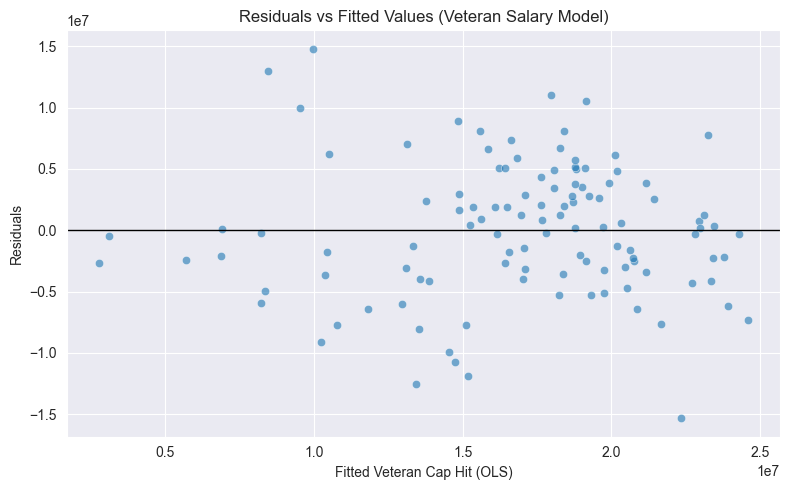

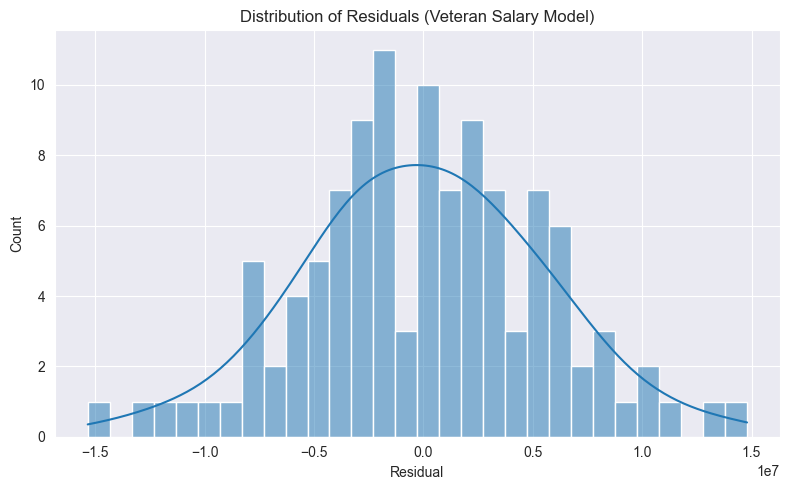

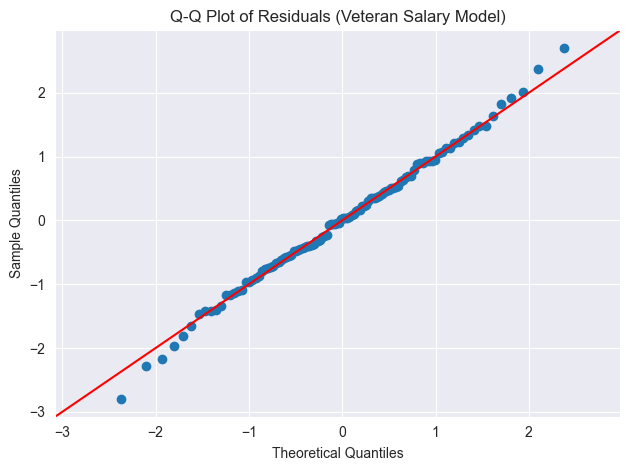

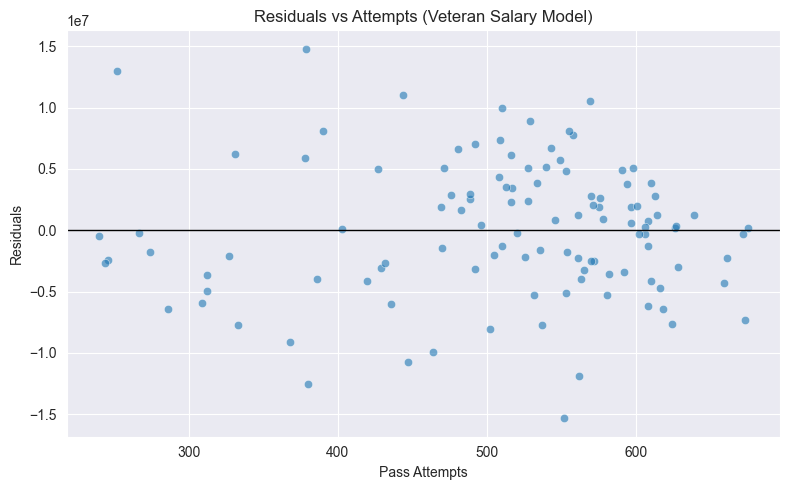


Breusch–Pagan test results:
  LM stat: 10.6663
  LM p-value: 0.0993
  F stat: 1.8420
  F p-value: 0.0979


In [62]:
# === Residual analysis for veteran salary model ===

from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make sure we use the same veteran sample and features as the final model
veteran_features = final_features  # or explicitly: ['Cmp', 'Cmp %', 'TD', 'int_rate', '1st', 'SckY']

X_vet = veteran_df[veteran_features].copy()
y_vet = veteran_df['cap_hit'].copy()

# Fit a simple OLS on the same features (for clean econ-style residuals)
X_ols = sm.add_constant(X_vet)
ols_vet_model = sm.OLS(y_vet, X_ols).fit()

print(ols_vet_model.summary())
print("\nAdj. R² (OLS, final feature set):", round(ols_vet_model.rsquared_adj, 3))

# Predictions and residuals
veteran_df['fitted_cap_ols'] = ols_vet_model.fittedvalues
veteran_df['residual_ols'] = ols_vet_model.resid

# 1) Residuals vs fitted values (check for nonlinearity, heteroskedasticity)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=veteran_df,
    x='fitted_cap_ols',
    y='residual_ols',
    alpha=0.6
)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Fitted Veteran Cap Hit (OLS)')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values (Veteran Salary Model)')
plt.tight_layout()
plt.show()

# 2) Histogram + KDE of residuals (normality-ish check)
plt.figure(figsize=(8, 5))
sns.histplot(veteran_df['residual_ols'], bins=30, kde=True)
plt.xlabel('Residual')
plt.title('Distribution of Residuals (Veteran Salary Model)')
plt.tight_layout()
plt.show()

# 3) Q-Q plot for residuals
sm.qqplot(veteran_df['residual_ols'], line='45', fit=True)
plt.title('Q-Q Plot of Residuals (Veteran Salary Model)')
plt.tight_layout()
plt.show()

# 4) Residuals vs attempts (check scale with workload)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=veteran_df,
    x='Att',
    y='residual_ols',
    alpha=0.6
)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Pass Attempts')
plt.ylabel('Residuals')
plt.title('Residuals vs Attempts (Veteran Salary Model)')
plt.tight_layout()
plt.show()

# 5) Breusch–Pagan test for heteroskedasticity
bp_test = het_breuschpagan(
    veteran_df['residual_ols'],
    X_ols
)
bp_labels = ['LM stat', 'LM p-value', 'F stat', 'F p-value']
bp_results = dict(zip(bp_labels, bp_test))
print("\nBreusch–Pagan test results:")
for k, v in bp_results.items():
    print(f"  {k}: {v:.4f}")


Surplus by year (actual dollar values):


,seasons,mean_surplus,median_surplus,pct_positive
years_since_draft,,,,
0.0,18,9381338.44,9603826.40,1.00
1.0,19,11190502.30,10628657.50,1.00
2.0,17,11371596.90,10589948.28,1.00
3.0,13,8804144.17,6537847.21,0.92


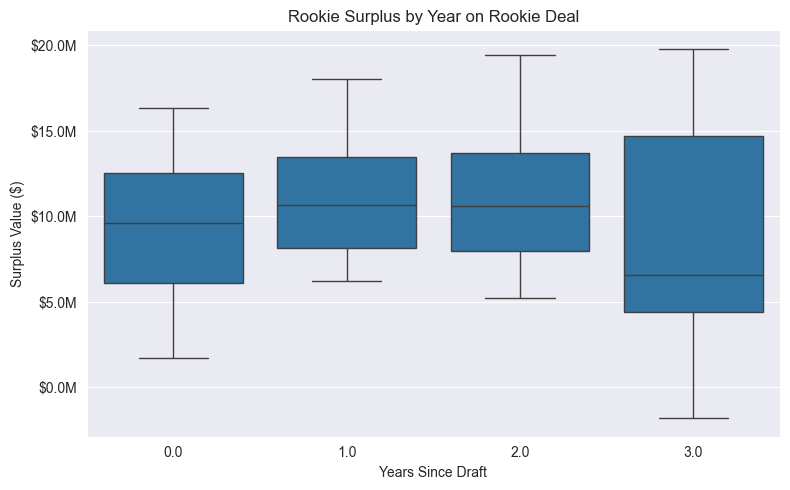


Surplus by year & draft round (actual dollars):


,years_since_draft,round_bucket,seasons,mean_surplus,median_surplus
0,0.0,R1,14,8265307.99,8402241.69
1,0.0,R2-3,2,11924216.51,11924216.51
2,0.0,R4-7,2,14650673.54,14650673.54
3,1.0,R1,12,10727550.31,9151994.92
4,1.0,R2-3,4,11493123.66,10264027.41
5,1.0,R4-7,3,12638815.07,12688085.41
6,2.0,R1,12,10782389.17,10513930.80
7,2.0,R2-3,3,12240079.03,13709828.78
8,2.0,R4-7,2,13604120.10,13604120.10
9,3.0,R1,7,6484485.89,4745098.69


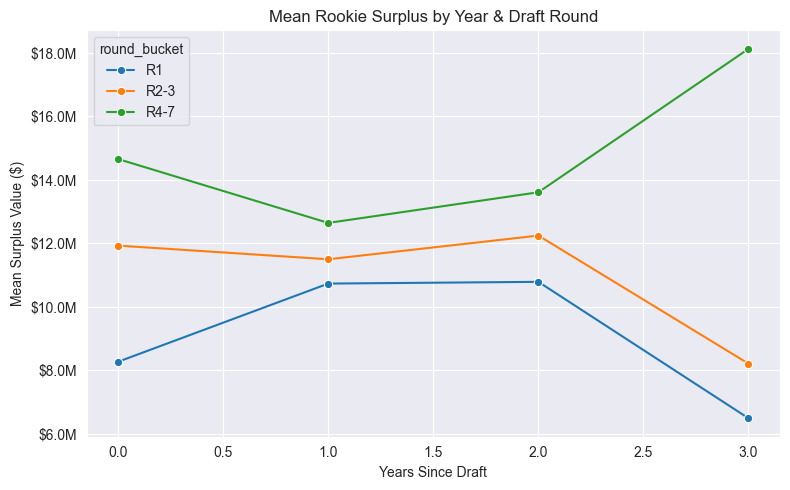

In [63]:
# === Rookie surplus by year on rookie deal (fixed scaling) ===

rookie_df_small = rookie_df[['name', 'year', 'team_short', 'draft_round',
                              'years_since_draft', 'surplus_value']].copy()

# Keep only rookie-contract window
rookie_df_small = rookie_df_small[
    rookie_df_small['years_since_draft'].between(0, 4, inclusive='both')
]

# Round buckets
def round_bucket(r):
    if pd.isna(r):
        return np.nan
    r = int(r)
    if r == 1:
        return "R1"
    elif r in [2, 3]:
        return "R2-3"
    else:
        return "R4-7"

rookie_df_small["round_bucket"] = rookie_df_small["draft_round"].apply(round_bucket)

# === Surplus summary by year ===
year_surplus = (
    rookie_df_small
    .groupby("years_since_draft")
    .agg(
        seasons=('name', 'count'),
        mean_surplus=('surplus_value', 'mean'),
        median_surplus=('surplus_value', 'median'),
        pct_positive=('surplus_value', lambda x: (x > 0).mean())
    )
)

print("Surplus by year (actual dollar values):")
display(year_surplus.round(2))

# === Boxplot of surplus by contract year ===
plt.figure(figsize=(8,5))
sns.boxplot(
    data=rookie_df_small,
    x="years_since_draft",
    y="surplus_value"
)
plt.xlabel("Years Since Draft")
plt.ylabel("Surplus Value ($)")
plt.title("Rookie Surplus by Year on Rookie Deal")

# Format y-axis nicely ($X.XM)
plt.gca().yaxis.set_major_formatter(
    lambda x, pos: f"${x/1e6:.1f}M"
)
plt.tight_layout()
plt.show()

# === Surplus by year AND draft round bucket ===
year_round_surplus = (
    rookie_df_small
    .groupby(["years_since_draft", "round_bucket"])
    .agg(
        seasons=('name', 'count'),
        mean_surplus=('surplus_value', 'mean'),
        median_surplus=('surplus_value', 'median')
    )
    .reset_index()
)

print("\nSurplus by year & draft round (actual dollars):")
display(year_round_surplus.round(2))

# === Line plot: mean surplus by year & round bucket ===
plt.figure(figsize=(8,5))
sns.lineplot(
    data=year_round_surplus,
    x="years_since_draft",
    y="mean_surplus",
    hue="round_bucket",
    marker="o"
)
plt.xlabel("Years Since Draft")
plt.ylabel("Mean Surplus Value ($)")
plt.title("Mean Rookie Surplus by Year & Draft Round")

# Format y-axis as $XM
plt.gca().yaxis.set_major_formatter(
    lambda x, pos: f"${x/1e6:.1f}M"
)
plt.tight_layout()
plt.show()


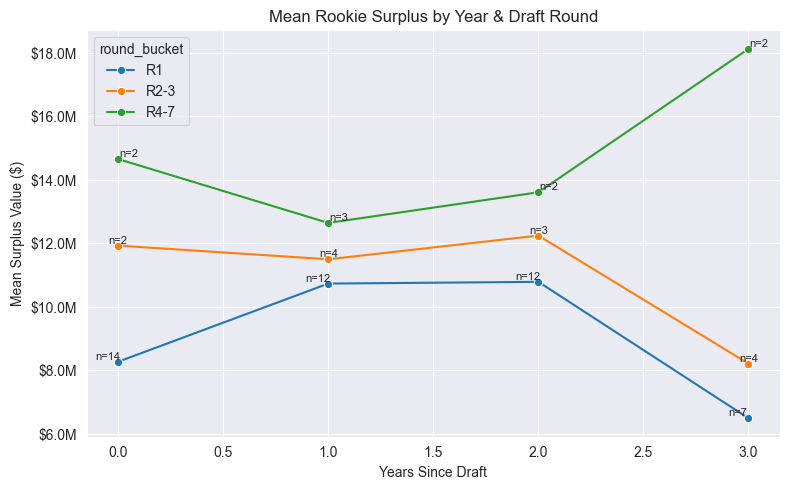

In [64]:
# === Line plot: mean surplus by year & round bucket WITH COUNTS ===
plt.figure(figsize=(8,5))

ax = sns.lineplot(
    data=year_round_surplus,
    x="years_since_draft",
    y="mean_surplus",
    hue="round_bucket",
    marker="o"
)

plt.xlabel("Years Since Draft")
plt.ylabel("Mean Surplus Value ($)")
plt.title("Mean Rookie Surplus by Year & Draft Round")

# Format y-axis as $XM
ax.yaxis.set_major_formatter(
    lambda x, pos: f"${x/1e6:.1f}M"
)

# --- Add n labels for each point ---
# small horizontal offsets so labels don't sit directly on top of each other
offset_map = {"R1": -0.05, "R2-3": 0.0, "R4-7": 0.05}

for _, row in year_round_surplus.iterrows():
    x = row["years_since_draft"] + offset_map.get(row["round_bucket"], 0.0)
    y = row["mean_surplus"]
    n = int(row["seasons"])
    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()


In [65]:
support_formula_2 = "surplus_pct ~ OL_pct + Offense_pct"
support_model_fe_2 = sm.OLS.from_formula(support_formula_2, data=support_df).fit()
print(support_model_fe_2.summary())

NameError: name 'support_df' is not defined

Number of rookie team-seasons with complete support data: 67

=== Support model with team fixed effects ===
                            OLS Regression Results                            
Dep. Variable:            surplus_pct   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     2.442
Date:                Wed, 10 Dec 2025   Prob (F-statistic):            0.00538
Time:                        11:34:15   Log-Likelihood:                 170.54
No. Observations:                  67   AIC:                            -285.1
Df Residuals:                      39   BIC:                            -223.3
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
------

,team_short,year,name,surplus_pct,intrinsic_surplus_pct,OL_pct,Offense_pct
23,Colts,2014,Andrew Luck,0.094238,0.083336,0.124508,0.340080
30,Dolphins,2014,Ryan Tannehill,0.127117,0.079917,0.143986,0.484963
8,Broncos,2016,Trevor Siemian,0.081716,0.072678,0.092032,0.340296
34,Eagles,2016,Carson Wentz,0.081439,0.066280,0.216964,0.420506
6,Bills,2020,Josh Allen,0.078885,0.064679,0.194975,0.487952
20,Chiefs,2018,Patrick Mahomes,0.101594,0.062416,0.197824,0.404137
31,Dolphins,2015,Ryan Tannehill,0.102587,0.061957,0.161638,0.329898
39,Jaguars,2015,Blake Bortles,0.090160,0.061567,0.173159,0.438746
62,Titans,2015,Marcus Mariota,0.045691,0.060047,0.077875,0.279329
44,Jets,2014,Geno Smith,0.058659,0.059959,0.203054,0.428470


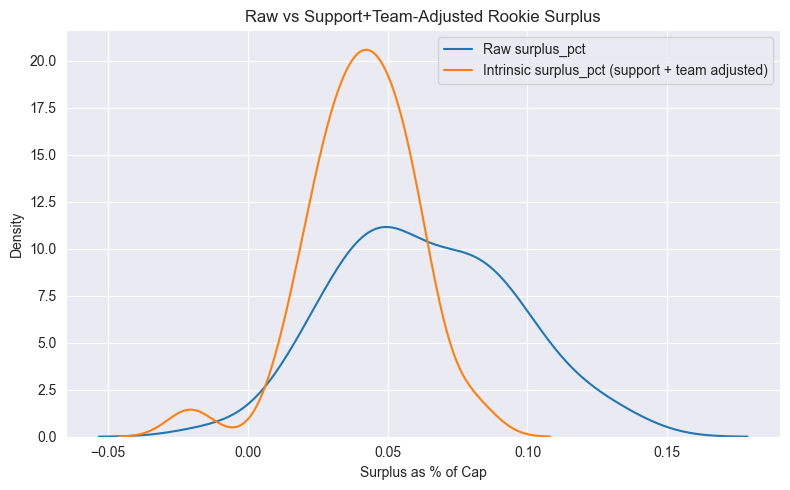


Top 15 rookies by intrinsic (support+team-adjusted) surplus_pct:


,team_short,year,name,surplus_pct,intrinsic_surplus_pct,OL_pct,Offense_pct
23,Colts,2014,Andrew Luck,0.094238,0.083336,0.124508,0.340080
30,Dolphins,2014,Ryan Tannehill,0.127117,0.079917,0.143986,0.484963
8,Broncos,2016,Trevor Siemian,0.081716,0.072678,0.092032,0.340296
34,Eagles,2016,Carson Wentz,0.081439,0.066280,0.216964,0.420506
6,Bills,2020,Josh Allen,0.078885,0.064679,0.194975,0.487952
20,Chiefs,2018,Patrick Mahomes,0.101594,0.062416,0.197824,0.404137
31,Dolphins,2015,Ryan Tannehill,0.102587,0.061957,0.161638,0.329898
39,Jaguars,2015,Blake Bortles,0.090160,0.061567,0.173159,0.438746
62,Titans,2015,Marcus Mariota,0.045691,0.060047,0.077875,0.279329
44,Jets,2014,Geno Smith,0.058659,0.059959,0.203054,0.428470



Top 15 rookies by raw surplus_pct:


,team_short,year,name,surplus_pct,intrinsic_surplus_pct,OL_pct,Offense_pct
57,Redskins,2015,Kirk Cousins,0.138135,0.040676,0.193777,0.487102
30,Dolphins,2014,Ryan Tannehill,0.127117,0.079917,0.143986,0.484963
50,Raiders,2015,Derek Carr,0.123514,0.045929,0.217448,0.377058
49,Raiders,2014,Derek Carr,0.119190,0.051701,0.130482,0.332616
28,Cowboys,2018,Dak Prescott,0.109534,0.053905,0.243565,0.411211
51,Raiders,2016,Derek Carr,0.107581,0.024397,0.238115,0.448551
58,Seahawks,2014,Russell Wilson,0.103081,0.044296,0.175486,0.369026
31,Dolphins,2015,Ryan Tannehill,0.102587,0.061957,0.161638,0.329898
20,Chiefs,2018,Patrick Mahomes,0.101594,0.062416,0.197824,0.404137
26,Cowboys,2016,Dak Prescott,0.099078,0.046026,0.137881,0.541726


In [64]:
# === Section F: Team-support–adjusted rookie surplus (WITH TEAM FIXED EFFECTS) ===

import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# We assume pct_df has one row per (team_short, year, name) for the rookie QB seasons,
# and contains columns: 'team_short', 'year', 'surplus_pct', 'OL_pct', 'Offense_pct'.

# 1) Build clean dataframe for support model
support_df = pct_df.dropna(subset=['team_short', 'surplus_pct', 'OL_pct', 'Offense_pct']).copy()

print("Number of rookie team-seasons with complete support data:", len(support_df))

# 2) Within-team fixed-effects model:
#    surplus_pct ~ OL_pct + Offense_pct + team fixed effects (C(team_short))
support_formula = "surplus_pct ~ OL_pct + Offense_pct + C(team_short)"
support_model_fe = sm.OLS.from_formula(support_formula, data=support_df).fit()

print("\n=== Support model with team fixed effects ===")
print(support_model_fe.summary())

# Extract key coefficients for interpretation
beta_ol = support_model_fe.params.get('OL_pct', float('nan'))
beta_off = support_model_fe.params.get('Offense_pct', float('nan'))

print("\nKey coefficients (controlling for team fixed effects):")
print(f"  Beta_OL_pct:      {beta_ol:.4f}")
print(f"  Beta_Offense_pct: {beta_off:.4f}")
print(f"  R-squared (FE):   {support_model_fe.rsquared:.3f}")

# 3) Compute "intrinsic" surplus component:
#    Remove the effect of OL and Offense spend AND team baselines.
#    After we subtract (all non-intercept terms), what's left is:
#      intrinsic_surplus_pct = intercept + residual
#    which is equivalent to "surplus after accounting for team + support context".
support_df['predicted_surplus_pct'] = support_model_fe.predict(support_df)

intercept_fe = support_model_fe.params['Intercept']

# Residuals (actual - predicted)
support_df['resid'] = support_model_fe.resid

# Intrinsic surplus = intercept + residual (constant shift; rankings depend on resid)
support_df['intrinsic_surplus_pct'] = intercept_fe + support_df['resid']

# 4) Build a clean comparison view
intrinsic_cols = [
    'team_short',
    'year',
    'name',
    'surplus_pct',
    'intrinsic_surplus_pct',
    'OL_pct',
    'Offense_pct'
]

intrinsic_surplus_df = support_df[intrinsic_cols].copy()

print("\nSample of raw vs intrinsic surplus_pct (support + team adjusted):")
display(
    intrinsic_surplus_df
    .sort_values('intrinsic_surplus_pct', ascending=False)
    .head(20)
)

# 5) Compare distributions: raw surplus vs support+team-adjusted surplus
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=intrinsic_surplus_df,
    x='surplus_pct',
    label='Raw surplus_pct'
)
sns.kdeplot(
    data=intrinsic_surplus_df,
    x='intrinsic_surplus_pct',
    label='Intrinsic surplus_pct (support + team adjusted)'
)
plt.xlabel('Surplus as % of Cap')
plt.title('Raw vs Support+Team-Adjusted Rookie Surplus')
plt.legend()
plt.tight_layout()
plt.show()

# 6) Top rookies by intrinsic vs raw surplus (for interpretation)
top_intrinsic = intrinsic_surplus_df.sort_values('intrinsic_surplus_pct', ascending=False).head(15)
top_raw = intrinsic_surplus_df.sort_values('surplus_pct', ascending=False).head(15)

print("\nTop 15 rookies by intrinsic (support+team-adjusted) surplus_pct:")
display(top_intrinsic)

print("\nTop 15 rookies by raw surplus_pct:")
display(top_raw)


In [65]:
# === Overlap between top raw surplus and top intrinsic surplus ===

# Choose N (you can adjust this)
N = 15

top_raw_set = set(
    intrinsic_surplus_df
    .sort_values("surplus_pct", ascending=False)
    .head(N)
    .apply(lambda row: (row["name"], row["year"]), axis=1)
)

top_intrinsic_set = set(
    intrinsic_surplus_df
    .sort_values("intrinsic_surplus_pct", ascending=False)
    .head(N)
    .apply(lambda row: (row["name"], row["year"]), axis=1)
)

# Intersection
overlap = top_raw_set & top_intrinsic_set

print(f"Top {N} Raw Surplus Count:       {len(top_raw_set)}")
print(f"Top {N} Intrinsic Surplus Count:  {len(top_intrinsic_set)}")
print(f"Overlap Count:                    {len(overlap)}")
print(f"Overlap Percentage:               {len(overlap) / N:.2%}")

print("\nPlayers appearing in BOTH lists (name, year):")
for item in overlap:
    print("  ", item)


Top 15 Raw Surplus Count:       15
Top 15 Intrinsic Surplus Count:  15
Overlap Count:                    5
Overlap Percentage:               33.33%

Players appearing in BOTH lists (name, year):
   ('Patrick Mahomes', 2018)
   ('Blake Bortles', 2015)
   ('Ryan Tannehill', 2015)
   ('Andrew Luck', 2014)
   ('Ryan Tannehill', 2014)


In [66]:
# === Rank correlation + Side-by-side rank comparison ===

# Work off intrinsic_surplus_df created in Section F
df_rank = intrinsic_surplus_df.copy()

# Compute ranks (1 = highest surplus)
df_rank["raw_rank"] = df_rank["surplus_pct"].rank(ascending=False, method="min")
df_rank["intrinsic_rank"] = df_rank["intrinsic_surplus_pct"].rank(ascending=False, method="min")

# Spearman correlation (non-parametric measure of rank-order similarity)
spearman_corr = df_rank[["raw_rank", "intrinsic_rank"]].corr(method="spearman").iloc[0, 1]

print(f"Spearman Rank Correlation (Raw vs Intrinsic Surplus): {spearman_corr:.3f}")

# Compute rank delta: positive = rises after adjustment, negative = falls
df_rank["rank_delta"] = df_rank["raw_rank"] - df_rank["intrinsic_rank"]

# Build a clean table
rank_comparison = (
    df_rank
    [["name", "year", "team_short", "surplus_pct", "intrinsic_surplus_pct",
      "raw_rank", "intrinsic_rank", "rank_delta"]]
    .sort_values("raw_rank")  # Sort by best raw performance
)

print("\n=== Side-by-Side Rank Comparison (Raw vs Intrinsic) ===")
display(rank_comparison.head(30))  # Show top 30; adjust if needed

# Also show biggest movers upward/downward
biggest_risers = (
    rank_comparison
    .sort_values("rank_delta", ascending=False)
    .head(10)
)

biggest_fallers = (
    rank_comparison
    .sort_values("rank_delta", ascending=True)
    .head(10)
)

print("\n=== Biggest Rank Risers (benefit from support-adjustment) ===")
display(biggest_risers)

print("\n=== Biggest Rank Fallers (lose ranking after adjustment) ===")
display(biggest_fallers)


Spearman Rank Correlation (Raw vs Intrinsic Surplus): 0.584

=== Side-by-Side Rank Comparison (Raw vs Intrinsic) ===


,name,year,team_short,surplus_pct,intrinsic_surplus_pct,raw_rank,intrinsic_rank,rank_delta
57,Kirk Cousins,2015,Redskins,0.138135,0.040676,1.0,35.0,-34.0
30,Ryan Tannehill,2014,Dolphins,0.127117,0.079917,2.0,2.0,0.0
50,Derek Carr,2015,Raiders,0.123514,0.045929,3.0,28.0,-25.0
49,Derek Carr,2014,Raiders,0.119190,0.051701,4.0,19.0,-15.0
28,Dak Prescott,2018,Cowboys,0.109534,0.053905,5.0,16.0,-11.0
51,Derek Carr,2016,Raiders,0.107581,0.024397,6.0,57.0,-51.0
58,Russell Wilson,2014,Seahawks,0.103081,0.044296,7.0,30.0,-23.0
31,Ryan Tannehill,2015,Dolphins,0.102587,0.061957,8.0,7.0,1.0
20,Patrick Mahomes,2018,Chiefs,0.101594,0.062416,9.0,6.0,3.0
26,Dak Prescott,2016,Cowboys,0.099078,0.046026,10.0,27.0,-17.0



=== Biggest Rank Risers (benefit from support-adjustment) ===


,name,year,team_short,surplus_pct,intrinsic_surplus_pct,raw_rank,intrinsic_rank,rank_delta
62,Marcus Mariota,2015,Titans,0.045691,0.060047,47.0,9.0,38.0
3,Mitchell Trubisky,2019,Bears,0.047196,0.055817,45.0,14.0,31.0
13,Jameis Winston,2015,Buccaneers,0.051330,0.056382,41.0,13.0,28.0
44,Geno Smith,2014,Jets,0.058659,0.059959,35.0,10.0,25.0
2,Mitchell Trubisky,2018,Bears,0.049426,0.051484,42.0,20.0,22.0
14,Jameis Winston,2016,Buccaneers,0.061478,0.058393,33.0,12.0,21.0
63,Marcus Mariota,2017,Titans,0.032171,0.039110,58.0,38.0,20.0
54,Jared Goff,2018,Rams,0.055307,0.052602,36.0,17.0,19.0
36,Daniel Jones,2019,Giants,0.060862,0.055801,34.0,15.0,19.0
53,Jared Goff,2017,Rams,0.051469,0.050452,40.0,22.0,18.0



=== Biggest Rank Fallers (lose ranking after adjustment) ===


,name,year,team_short,surplus_pct,intrinsic_surplus_pct,raw_rank,intrinsic_rank,rank_delta
51,Derek Carr,2016,Raiders,0.107581,0.024397,6.0,57.0,-51.0
29,Dak Prescott,2019,Cowboys,0.087418,0.024238,17.0,58.0,-41.0
57,Kirk Cousins,2015,Redskins,0.138135,0.040676,1.0,35.0,-34.0
59,Russell Wilson,2015,Seahawks,0.087821,0.037055,15.0,42.0,-27.0
27,Dak Prescott,2017,Cowboys,0.087423,0.038533,16.0,41.0,-25.0
50,Derek Carr,2015,Raiders,0.123514,0.045929,3.0,28.0,-25.0
61,Deshaun Watson,2019,Texans,0.072885,0.029189,27.0,51.0,-24.0
58,Russell Wilson,2014,Seahawks,0.103081,0.044296,7.0,30.0,-23.0
21,Patrick Mahomes,2019,Chiefs,0.065668,0.027064,31.0,54.0,-23.0
65,Teddy Bridgewater,2014,Vikings,0.085334,0.039016,18.0,39.0,-21.0


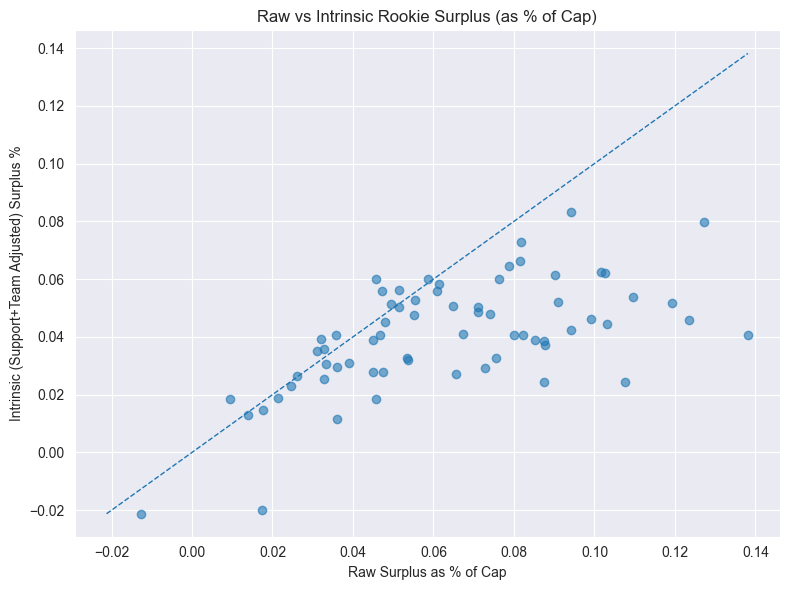

In [67]:
# === Scatter: Raw vs Intrinsic Surplus % (with reference line) ===

plt.figure(figsize=(8, 6))

ax = plt.gca()

ax.scatter(
    intrinsic_surplus_df['surplus_pct'],
    intrinsic_surplus_df['intrinsic_surplus_pct'],
    alpha=0.6
)

# 45-degree line (where raw == intrinsic)
min_val = min(intrinsic_surplus_df['surplus_pct'].min(),
              intrinsic_surplus_df['intrinsic_surplus_pct'].min())
max_val = max(intrinsic_surplus_df['surplus_pct'].max(),
              intrinsic_surplus_df['intrinsic_surplus_pct'].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=1)

ax.set_xlabel('Raw Surplus as % of Cap')
ax.set_ylabel('Intrinsic (Support+Team Adjusted) Surplus %')
ax.set_title('Raw vs Intrinsic Rookie Surplus (as % of Cap)')

plt.tight_layout()
plt.show()


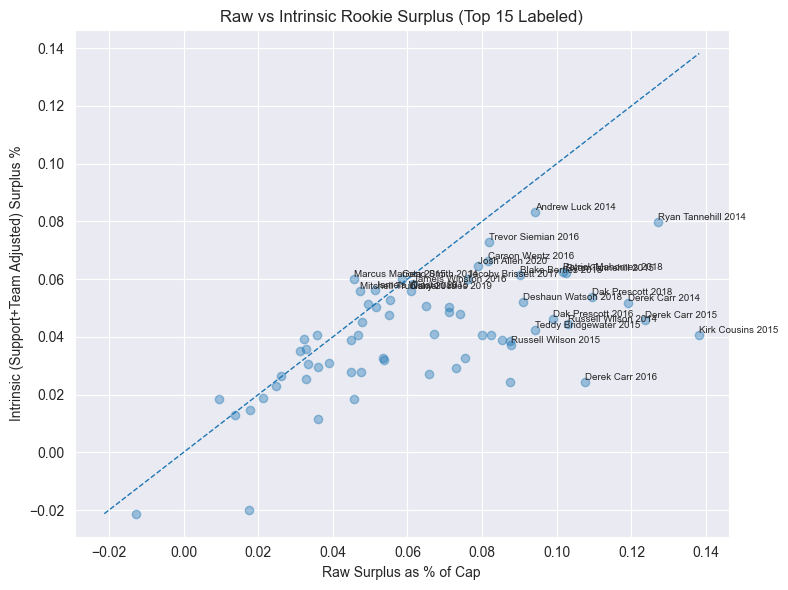

In [68]:
# === Scatter with labels for top N rookies by either metric ===

N = 15  # number of points to label

# Build a subset of rows to annotate: union of top N raw and top N intrinsic
top_raw_idx = intrinsic_surplus_df['surplus_pct'].nlargest(N).index
top_intr_idx = intrinsic_surplus_df['intrinsic_surplus_pct'].nlargest(N).index
label_idx = top_raw_idx.union(top_intr_idx)

plt.figure(figsize=(8, 6))
ax = plt.gca()

ax.scatter(
    intrinsic_surplus_df['surplus_pct'],
    intrinsic_surplus_df['intrinsic_surplus_pct'],
    alpha=0.4
)

# 45-degree line
min_val = min(intrinsic_surplus_df['surplus_pct'].min(),
              intrinsic_surplus_df['intrinsic_surplus_pct'].min())
max_val = max(intrinsic_surplus_df['surplus_pct'].max(),
              intrinsic_surplus_df['intrinsic_surplus_pct'].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=1)

# Annotate selected points
for idx in label_idx:
    row = intrinsic_surplus_df.loc[idx]
    x = row['surplus_pct']
    y = row['intrinsic_surplus_pct']
    label = f"{row['name']} {int(row['year'])}"
    ax.text(
        x,
        y,
        label,
        fontsize=7,
        ha='left',
        va='bottom'
    )

ax.set_xlabel('Raw Surplus as % of Cap')
ax.set_ylabel('Intrinsic (Support+Team Adjusted) Surplus %')
ax.set_title(f'Raw vs Intrinsic Rookie Surplus (Top {N} Labeled)')

plt.tight_layout()
plt.show()


In [69]:
# Map whatever is in team_short to standard NFL 3-letter codes used by nflfastR logos
team_code_map = {
    # Common nickname → abbr
    "Bills": "BUF",
    "Dolphins": "MIA",
    "Patriots": "NE",
    "Jets": "NYJ",
    "Ravens": "BAL",
    "Bengals": "CIN",
    "Browns": "CLE",
    "Steelers": "PIT",
    "Texans": "HOU",
    "Colts": "IND",
    "Jaguars": "JAX",
    "Titans": "TEN",
    "Broncos": "DEN",
    "Chiefs": "KC",
    "Raiders": "LV",      # or "OAK" if your data is older
    "Chargers": "LAC",
    "Cowboys": "DAL",
    "Giants": "NYG",
    "Eagles": "PHI",
    "Commanders": "WAS",   # "Redskins" → "WAS" if older
    "Commanders*": "WAS",  # in case of weird labels
    "Bears": "CHI",
    "Lions": "DET",
    "Packers": "GB",
    "Vikings": "MIN",
    "Falcons": "ATL",
    "Panthers": "CAR",
    "Saints": "NO",
    "Buccaneers": "TB",
    "Cardinals": "ARI",
    "Rams": "LAR",
    "Seahawks": "SEA",
    "49Ers": "SF",
    "Redskins": "WAS",

}


In [70]:
import requests
from io import BytesIO
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.pyplot as plt

def get_fastR_logo(team_abbr, zoom=0.07):
    # nflfastR uses lowercase filenames
    abbr = team_abbr.lower()
    url = f"https://raw.githubusercontent.com/nflverse/nflfastR-data/master/teams/logos/{abbr}.png"
    try:
        r = requests.get(url)
        r.raise_for_status()
        img = plt.imread(BytesIO(r.content))
        return OffsetImage(img, zoom=zoom)
    except Exception as e:
        print(f"Failed to load logo for {team_abbr}: {e}")
        return None


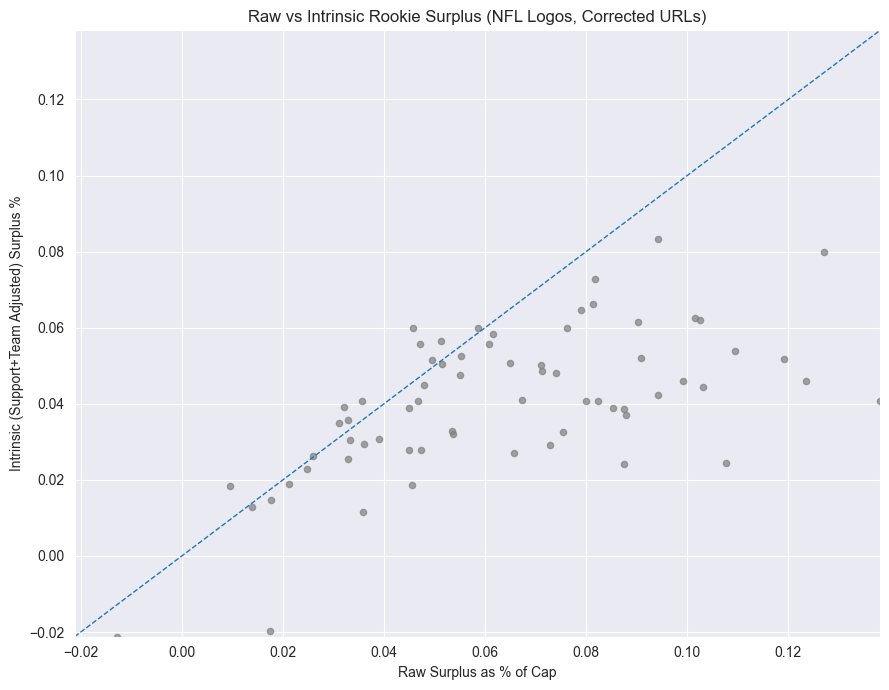

In [71]:
plt.figure(figsize=(9, 7))
ax = plt.gca()

x_vals = intrinsic_surplus_df['surplus_pct']
y_vals = intrinsic_surplus_df['intrinsic_surplus_pct']

min_val = min(x_vals.min(), y_vals.min())
max_val = max(x_vals.max(), y_vals.max())

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# 45-degree reference line
ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=1)

for _, row in intrinsic_surplus_df.iterrows():
    x = row['surplus_pct']
    y = row['intrinsic_surplus_pct']
    raw_code = row['team_short']

    # Convert your team_short into lowercase nflfastR code
    abbr = team_code_map.get(raw_code.upper())
    if not abbr:
        ax.scatter(x, y, s=20, color='gray', alpha=0.7)
        continue

    logo_img = get_fastR_logo(abbr, zoom=0.06)
    if logo_img is not None:
        ab = AnnotationBbox(logo_img, (x, y), frameon=False)
        ax.add_artist(ab)
    else:
        ax.scatter(x, y, s=20, color='gray', alpha=0.7)

ax.set_xlabel('Raw Surplus as % of Cap')
ax.set_ylabel('Intrinsic (Support+Team Adjusted) Surplus %')
ax.set_title('Raw vs Intrinsic Rookie Surplus (NFL Logos, Corrected URLs)')

plt.tight_layout()
plt.show()


In [72]:
import pandas as pd
import requests
from io import BytesIO
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# 1) Load the teams_colors_logos.csv from nflverse
logos_csv_url = "https://raw.githubusercontent.com/nflverse/nflverse-pbp/master/teams_colors_logos.csv"
teams = pd.read_csv(logos_csv_url)

# Inspect column names if you want
print("Columns in teams_colors_logos.csv:")
print(list(teams.columns))

# 2) Identify:
#    - team abbreviation column (first column in this file)
#    - squared_logo column (the one whose values contain 'squared_logos')
abbr_col = teams.columns[0]

sq_logo_col = None
for col in teams.columns:
    # find the column that contains 'squared_logos' in any row
    if teams[col].astype(str).str.contains("squared_logos").any():
        sq_logo_col = col
        break

print(f"\nUsing '{abbr_col}' as team abbr column")
print(f"Using '{sq_logo_col}' as squared logo URL column")

# 3) Create a slim lookup table: team_abbr -> squared_logo_url
team_logos = teams[[abbr_col, sq_logo_col]].rename(
    columns={abbr_col: "team_abbr", sq_logo_col: "logo_sq_url"}
)


Columns in teams_colors_logos.csv:
['team_abbr', 'team_name', 'team_id', 'team_nick', 'team_conf', 'team_division', 'team_color', 'team_color2', 'team_color3', 'team_color4', 'team_logo_wikipedia', 'team_logo_espn', 'team_wordmark', 'team_conference_logo', 'team_league_logo', 'team_logo_squared']

Using 'team_abbr' as team abbr column
Using 'team_logo_squared' as squared logo URL column


In [73]:
# Map whatever is in team_short to standard NFL 3-letter codes used by nflfastR logos
team_code_map = {
    # Common nickname → abbr
    "Bills": "BUF",
    "Dolphins": "MIA",
    "Patriots": "NE",
    "Jets": "NYJ",
    "Ravens": "BAL",
    "Bengals": "CIN",
    "Browns": "CLE",
    "Steelers": "PIT",
    "Texans": "HOU",
    "Colts": "IND",
    "Jaguars": "JAX",
    "Titans": "TEN",
    "Broncos": "DEN",
    "Chiefs": "KC",
    "Raiders": "LV",      # or "OAK" if your data is older
    "Chargers": "LAC",
    "Cowboys": "DAL",
    "Giants": "NYG",
    "Eagles": "PHI",
    "Commanders": "WAS",   # "Redskins" → "WAS" if older
    "Commanders*": "WAS",  # in case of weird labels
    "Bears": "CHI",
    "Lions": "DET",
    "Packers": "GB",
    "Vikings": "MIN",
    "Falcons": "ATL",
    "Panthers": "CAR",
    "Saints": "NO",
    "Buccaneers": "TB",
    "Cardinals": "ARI",
    "Rams": "LAR",
    "Seahawks": "SEA",
    "49Ers": "SF",
    "Redskins": "WAS",
    "Team": "WAS"

}


In [74]:
# Make a new column team_abbr without touching team_short
intrinsic_surplus_df['team_abbr'] = (
    intrinsic_surplus_df['team_short']
    .astype(str)
    .map(team_code_map)
)


In [75]:
import pandas as pd

logos_csv_url = "https://raw.githubusercontent.com/nflverse/nflverse-pbp/master/teams_colors_logos.csv"
teams = pd.read_csv(logos_csv_url)

# Find column containing squared logos
sq_logo_col = [c for c in teams.columns if teams[c].astype(str).str.contains("squared_logos").any()][0]

# Build lookup table
logo_lookup = teams[[teams.columns[0], sq_logo_col]].rename(
    columns={teams.columns[0]: "nflverse_abbr", sq_logo_col: "logo_url"}
)

# Merge: team_abbr (lowercase) vs nflverse_abbr (uppercase)
intrinsic_surplus_df['team_abbr_up'] = intrinsic_surplus_df['team_abbr'].str.upper()

intrinsic_with_logos = intrinsic_surplus_df.merge(
    logo_lookup,
    left_on="team_abbr_up",
    right_on="nflverse_abbr",
    how="left"
)

print(intrinsic_with_logos[['team_short', 'team_abbr', 'logo_url']].head(20))



    team_short team_abbr                                           logo_url
0        49Ers        SF  https://github.com/nflverse/nflverse-pbp/raw/m...
1        Bears       CHI  https://github.com/nflverse/nflverse-pbp/raw/m...
2        Bears       CHI  https://github.com/nflverse/nflverse-pbp/raw/m...
3        Bears       CHI  https://github.com/nflverse/nflverse-pbp/raw/m...
4        Bills       BUF  https://github.com/nflverse/nflverse-pbp/raw/m...
5        Bills       BUF  https://github.com/nflverse/nflverse-pbp/raw/m...
6        Bills       BUF  https://github.com/nflverse/nflverse-pbp/raw/m...
7      Broncos       DEN  https://github.com/nflverse/nflverse-pbp/raw/m...
8      Broncos       DEN  https://github.com/nflverse/nflverse-pbp/raw/m...
9      Broncos       DEN  https://github.com/nflverse/nflverse-pbp/raw/m...
10      Browns       CLE  https://github.com/nflverse/nflverse-pbp/raw/m...
11      Browns       CLE  https://github.com/nflverse/nflverse-pbp/raw/m...
12      Brow

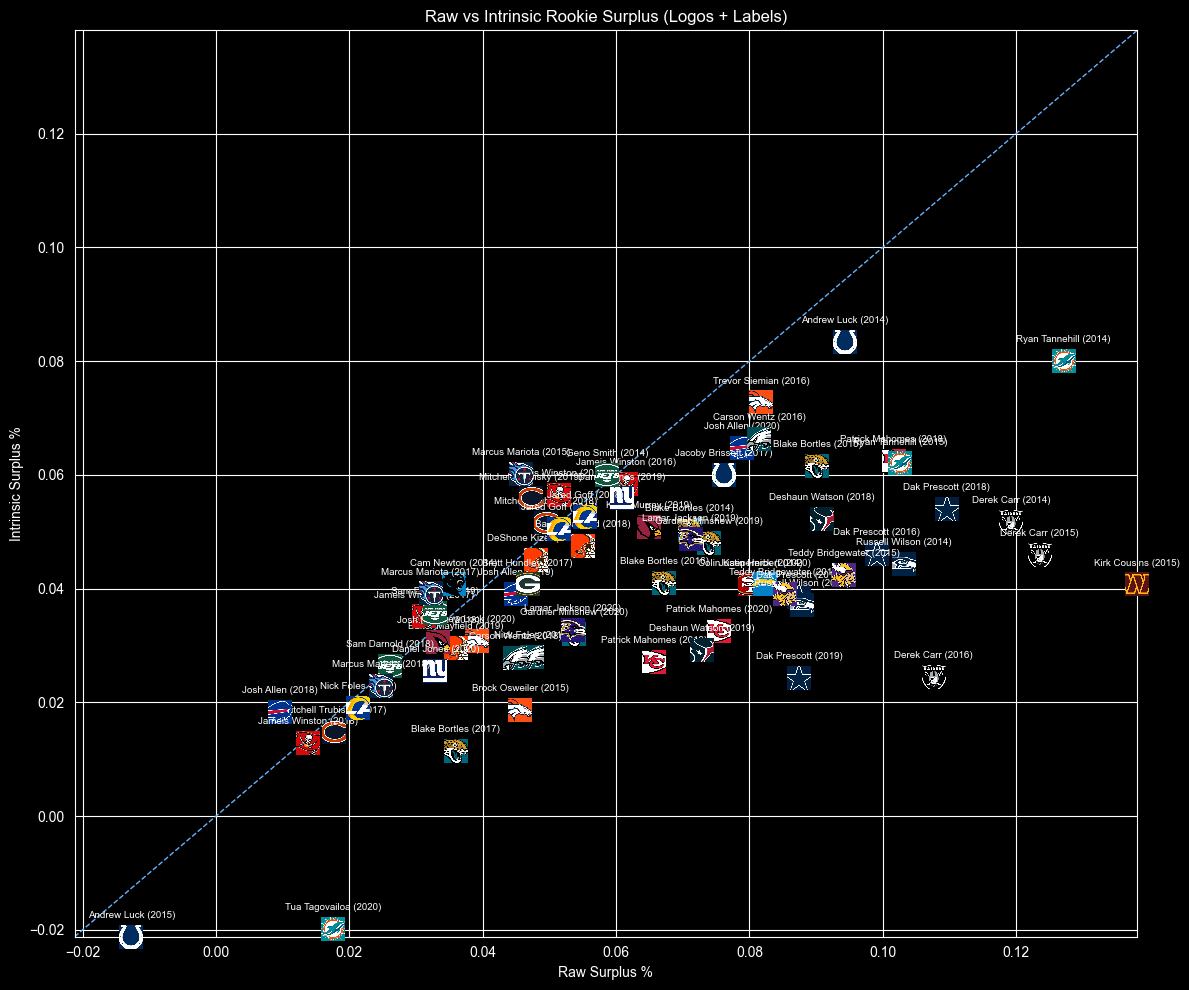

In [76]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import requests
from io import BytesIO

plt.style.use("dark_background")   # <<< DARK MODE

def get_logo(url, zoom=0.085):
    if not isinstance(url, str):
        return None
    try:
        r = requests.get(url)
        r.raise_for_status()
        img = plt.imread(BytesIO(r.content))
        return OffsetImage(img, zoom=zoom)
    except:
        return None

plt.figure(figsize=(12, 10))
ax = plt.gca()

x_vals = intrinsic_with_logos['surplus_pct']
y_vals = intrinsic_with_logos['intrinsic_surplus_pct']

min_val = min(x_vals.min(), y_vals.min())
max_val = max(x_vals.max(), y_vals.max())

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# 45-degree line
ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=1, color="#66b2ff")

for _, row in intrinsic_with_logos.iterrows():
    x = row['surplus_pct']
    y = row['intrinsic_surplus_pct']
    url = row['logo_url']
    player = row['name']
    year = int(row['year'])

    # Draw logo
    logo_img = get_logo(url, zoom=0.085)
    if logo_img is not None:
        ab = AnnotationBbox(logo_img, (x, y), frameon=False)
        ax.add_artist(ab)
    else:
        ax.scatter(x, y, s=40, color='gray', alpha=0.7)

    # Label
    label = f"{player} ({year})"
    ax.text(
        x,
        y + 0.003,
        label,
        fontsize=7,
        ha='center',
        va='bottom',
        color='white'
    )

ax.set_xlabel("Raw Surplus %")
ax.set_ylabel("Intrinsic Surplus %")
ax.set_title("Raw vs Intrinsic Rookie Surplus (Logos + Labels)")

plt.tight_layout()
plt.show()
